# Comparing Solar Potential Across Countries

This notebook synthesizes cleaned datasets from Benin, Sierra Leone, and Togo to identify relative solar potential and key differences across countries.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

# Load cleaned datasets
benin = pd.read_csv('../../data/benin_clean.csv')
sierra_leone = pd.read_csv('../../data/sierraleone_clean.csv')
togo = pd.read_csv('../../data/togo_clean.csv')

# Add a 'Country' column to each dataset
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine datasets
df = pd.concat([benin, sierra_leone, togo], ignore_index=True)
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,outlier,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,122.1,0.0,998,0,0.0,26.3,26.2,NaN,False,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,0.0,0.0,998,0,0.0,26.3,26.2,NaN,False,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,124.6,1.5,997,0,0.0,26.4,26.2,NaN,False,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,120.3,1.3,997,0,0.0,26.4,26.3,NaN,False,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,113.2,1.0,997,0,0.0,26.4,26.3,NaN,False,Benin


## Metric Comparison

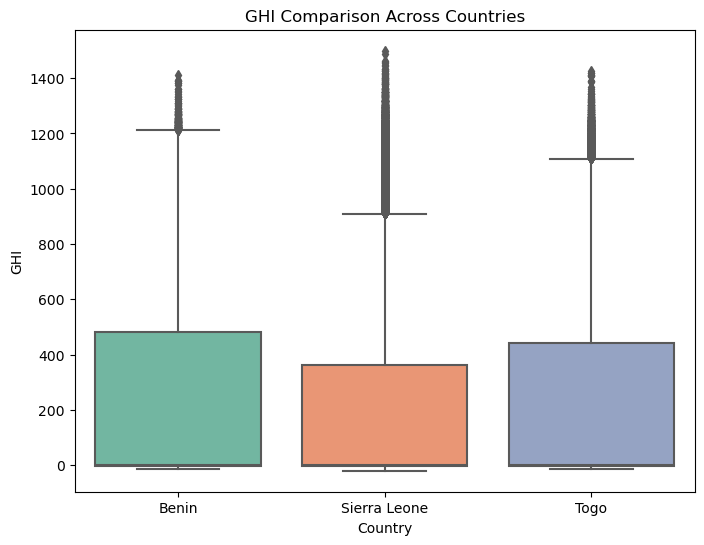

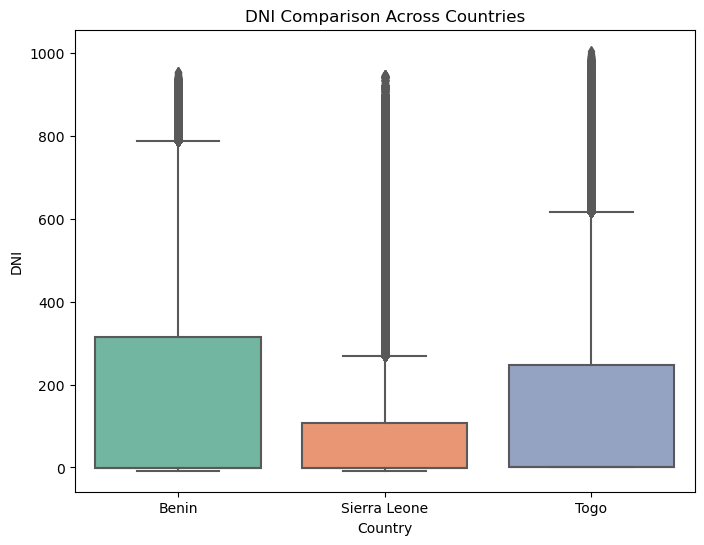

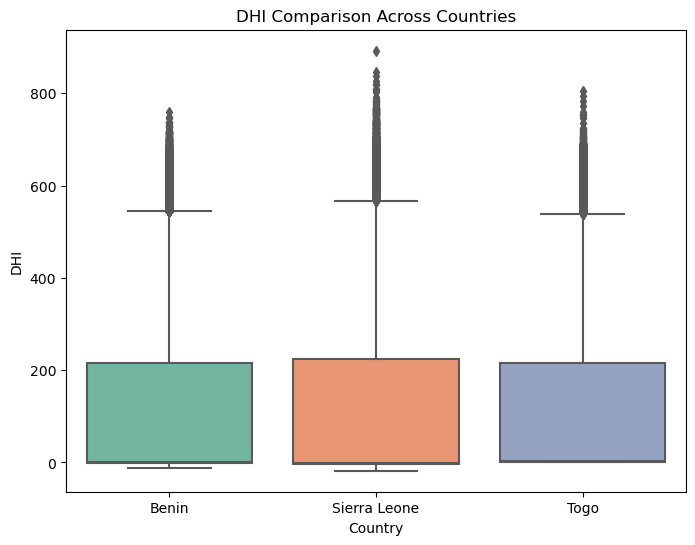

In [2]:
# Boxplots for GHI, DNI, DHI
metrics = ['GHI', 'DNI', 'DHI']
for metric in metrics:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Country', y=metric, palette='Set2')
    plt.title(f'{metric} Comparison Across Countries')
    plt.ylabel(metric)
    plt.xlabel('Country')
    plt.show()

In [3]:
# Summary Table for GHI, DNI, DHI
summary_table = df.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std'])
summary_table.columns = ['_'.join(col).strip() for col in summary_table.columns.values]
summary_table.reset_index(inplace=True)
print(summary_table)

        Country    GHI_mean  GHI_median     GHI_std    DNI_mean  DNI_median  \
0         Benin  240.559452         1.8  331.131327  167.187516        -0.1   
1  Sierra Leone  201.957515         0.3  298.495150  116.376337        -0.1   
2          Togo  230.555040         2.1  322.532347  151.258469         0.0   

      DNI_std    DHI_mean  DHI_median     DHI_std  
0  261.710501  115.358961         1.6  158.691074  
1  218.652659  113.720571        -0.1  158.946032  
2  250.956962  116.444352         2.5  156.520714  


## Statistical Testing

In [4]:
# One-way ANOVA for GHI
f_stat, p_value = f_oneway(benin['GHI'], sierra_leone['GHI'], togo['GHI'])
print(f"ANOVA Results for GHI: F-statistic = {f_stat:.2f}, p-value = {p_value:.4f}")

# Kruskal-Wallis test (non-parametric alternative)
h_stat, p_value_kruskal = kruskal(benin['GHI'], sierra_leone['GHI'], togo['GHI'])
print(f"Kruskal-Wallis Results for GHI: H-statistic = {h_stat:.2f}, p-value = {p_value_kruskal:.4f}")

ANOVA Results for GHI: F-statistic = 2090.09, p-value = 0.0000
Kruskal-Wallis Results for GHI: H-statistic = 4524.88, p-value = 0.0000


## Key Observations

- Benin shows the highest median GHI but also the greatest variability.
- Sierra Leone has the lowest average DNI, indicating less direct solar radiation.
- Togo demonstrates consistent solar potential with moderate variability across metrics.

## Visual Summary

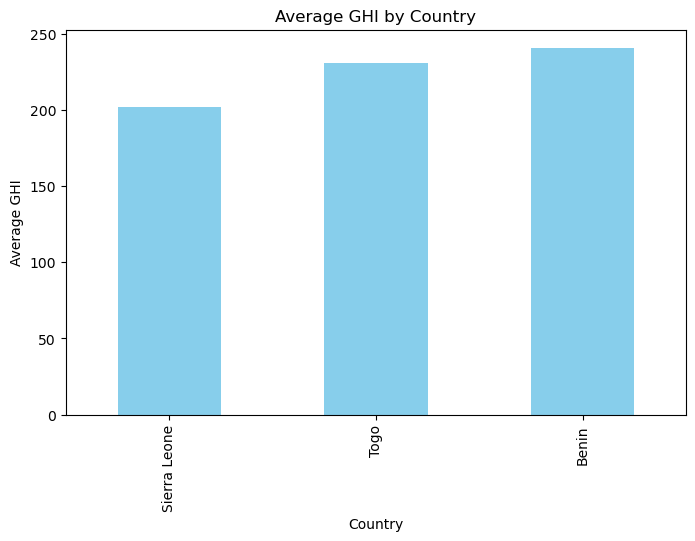

In [5]:
# Bar chart ranking countries by average GHI
avg_ghi = df.groupby('Country')['GHI'].mean().sort_values()
avg_ghi.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Average GHI by Country')
plt.ylabel('Average GHI')
plt.xlabel('Country')
plt.show()